In [1]:
from glob import glob

import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader

from compgen.model.composition_model import CompositionModel
from compgen.data.dataset import CompositionDataset
from compgen.train.trainer import Trainer

In [2]:
# Dataset.
dataset =  CompositionDataset(data_path= './data/mp_20/train.csv')

train_loader = DataLoader(
    dataset,
    batch_size = 32,
    pin_memory = True,
    shuffle = True,
)

In [3]:
# Model.
composition_model = CompositionModel(
    elem_emb_len=200, 
    elem_fea_len=32, 
    n_graph = 3,
    elem_heads=3,
    elem_gate=[64],
    elem_msg=[64],
    cry_heads=3,
    cry_gate=[64],
    cry_msg=[64],
    activation = nn.SiLU,
    batchnorm = False,
)

In [4]:
trainer = Trainer(
    model=composition_model,
    optimizer='Adam',
    epochs = 10,
    learning_rate=1e-4,
    print_freq=30,
    torch_seed=42,
    data_seed=42,
    weight_decay=1e-6,
)

In [5]:
trainer.train(train_loader)

Begin Training: using cuda device


Epoch: [1][1/848]	Time (1.177) Data (0.041) Loss 1.7172 (1.7172) KL Loss 0.0071 (0.0071) Comp Loss 0.0030 (0.0030) Ave V Loss 1.0089 (1.0089)
Epoch: [1][30/848]	Time (0.130) Data (0.050) Loss 1.2040 (1.5577) KL Loss 0.0057 (0.0063) Comp Loss 0.0028 (0.0029) Ave V Loss 0.6351 (0.9203)
Epoch: [1][60/848]	Time (0.120) Data (0.056) Loss 1.5448 (1.5552) KL Loss 0.0042 (0.0056) Comp Loss 0.0029 (0.0030) Ave V Loss 1.1245 (0.9892)
Epoch: [1][90/848]	Time (0.113) Data (0.056) Loss 1.6306 (1.4680) KL Loss 0.0024 (0.0048) Comp Loss 0.0030 (0.0029) Ave V Loss 1.3886 (0.9809)
Epoch: [1][120/848]	Time (0.111) Data (0.057) Loss 0.7220 (1.3813) KL Loss 0.0011 (0.0041) Comp Loss 0.0031 (0.0029) Ave V Loss 0.6070 (0.9731)
Epoch: [1][150/848]	Time (0.112) Data (0.059) Loss 0.7824 (1.2952) KL Loss 0.0004 (0.0034) Comp Loss 0.0028 (0.0029) Ave V Loss 0.7411 (0.9540)
Epoch: [1][180/848]	Time (0.112) Data (0.060) Loss 0.9158 (1.2613) KL Loss 0.0001 (0.0029) Comp Loss 0.0029 (0.0029) Ave V Loss 0.9044 (0.973

In [6]:
from tqdm import tqdm
model_path = glob('./*/best*')[0]
composition_model = CompositionModel.from_file(model_path)
composition_model.v_scaler = dataset.v_scaler
comp, ave_v, atom_types = composition_model.sample(num_samples=60, num_atoms=3)
atom_types = torch.stack(atom_types, dim=0)
comp, ave_v, atom_types

(tensor([[0.0061, 0.0039, 0.0205,  ..., 0.0037, 0.0038, 0.0038],
         [0.0075, 0.0039, 0.0194,  ..., 0.0035, 0.0035, 0.0036],
         [0.0056, 0.0031, 0.0245,  ..., 0.0030, 0.0030, 0.0030],
         ...,
         [0.0068, 0.0035, 0.0235,  ..., 0.0033, 0.0033, 0.0033],
         [0.0075, 0.0039, 0.0215,  ..., 0.0037, 0.0037, 0.0037],
         [0.0062, 0.0040, 0.0213,  ..., 0.0038, 0.0038, 0.0038]]),
 tensor([[20.4692],
         [20.3217],
         [19.7356],
         [19.7336],
         [20.0182],
         [20.1509],
         [19.7504],
         [20.4750],
         [20.2540],
         [20.8264],
         [20.3398],
         [19.7137],
         [19.7366],
         [20.5950],
         [19.6341],
         [21.1081],
         [21.6656],
         [20.0927],
         [20.2225],
         [20.2203],
         [19.0117],
         [19.8375],
         [20.2152],
         [20.1409],
         [19.8580],
         [19.6191],
         [19.9492],
         [21.0259],
         [20.5234],
         [20.4

### Dimensionality Reduction
1. PCA
2. t-SNE

In [8]:
from tqdm import tqdm
model_path = glob('./*/best*')[0]
composition_model = CompositionModel.from_file(model_path).to('cuda')
composition_model.v_scaler = dataset.v_scaler

mus = []
for batch in tqdm(train_loader):
    mu, _ = composition_model.encode(batch.cuda())
    mus.append(mu)
mus = torch.cat(mus, dim=0)

100%|██████████| 848/848 [00:08<00:00, 100.96it/s]


In [9]:
# Dataset.
dataset_LiMnO =  CompositionDataset(data_path= './data/LiMnO.csv')

train_loader_LiMnO = DataLoader(
    dataset_LiMnO,
    batch_size = 32,
    pin_memory = True,
    shuffle = True,
)

mus_LiMnO = []
for batch in tqdm(train_loader_LiMnO):
    mu, _ = composition_model.encode(batch.cuda())
    mus_LiMnO.append(mu)
mus_LiMnO = torch.cat(mus_LiMnO, dim=0)

100%|██████████| 1/1 [00:00<00:00, 72.86it/s]


In [10]:
# Dataset.
dataset_CdS =  CompositionDataset(data_path= './data/CdS.csv')

train_loader_CdS = DataLoader(
    dataset_CdS,
    batch_size = 32,
    pin_memory = True,
    shuffle = True,
)

mus_CdS = []
for batch in tqdm(train_loader_CdS):
    mu, _ = composition_model.encode(batch.cuda())
    mus_CdS.append(mu)
mus_CdS = torch.cat(mus_CdS, dim=0)

100%|██████████| 1/1 [00:00<00:00, 74.80it/s]


In [11]:
# Dataset.
dataset_VO =  CompositionDataset(data_path= './data/VO.csv')

train_loader_VO = DataLoader(
    dataset_VO,
    batch_size = 32,
    pin_memory = True,
    shuffle = True,
)

mus_VO = []
for batch in tqdm(train_loader_VO):
    mu, _ = composition_model.encode(batch.cuda())
    mus_VO.append(mu)
mus_VO = torch.cat(mus_VO, dim=0)

100%|██████████| 1/1 [00:00<00:00, 60.88it/s]


In [12]:
# PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
mus_pca = pca.fit_transform(mus.cpu().detach().numpy())
mus_pca_LiMnO = pca.transform(mus_LiMnO.cpu().detach().numpy())
mus_pca_CdS = pca.transform(mus_CdS.cpu().detach().numpy())
mus_pca_VO = pca.transform(mus_VO.cpu().detach().numpy())

print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.9823882  0.01128889]
[2.702997   0.28975406]


(-0.033602907229214905,
 0.11175487646833063,
 -0.019819942023605108,
 0.02373972786590457)

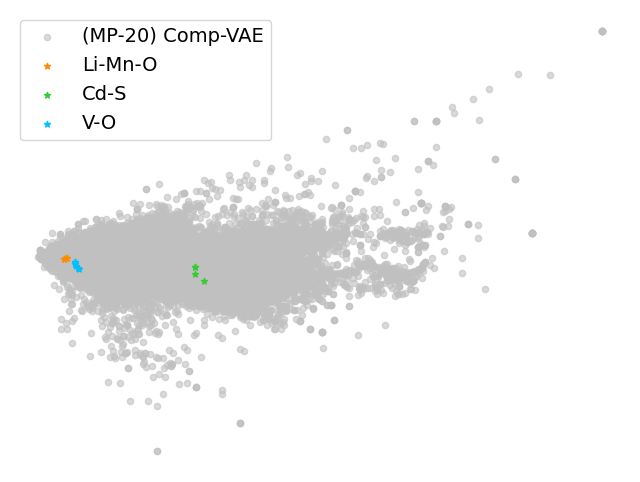

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(mus_pca[:,0], mus_pca[:,1], s=20, color='silver', marker="o", alpha=0.6, label="(MP-20) Comp-VAE")
plt.scatter(mus_pca_LiMnO[:,0], mus_pca_LiMnO[:,1], s=20, marker='*', color="darkorange", alpha=1.0, label="Li-Mn-O")
plt.scatter(mus_pca_CdS[:,0], mus_pca_CdS[:,1], s=20, marker='*', color="limegreen", alpha=1.0, label="Cd-S")
plt.scatter(mus_pca_VO[:,0], mus_pca_VO[:,1], s=20, marker='*', color="deepskyblue", alpha=1.0, label="V-O")
plt.legend(fontsize=14)
plt.axis('off')

In [ ]:
ids = mus_pca[:,0].argsort()[-10:]
outliers = []
for id in ids:
    outliers.append(dataset[id])
outliers

[Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 118], ave_v=[1], cry_id='mp-569147', cry_name='UP2'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 118], ave_v=[1], cry_id='mp-756638', cry_name='NbRhO4'),
 Data(x=[5, 200], edge_index=[2, 25], elem_weights=[5, 1], comp=[1, 118], ave_v=[1], cry_id='mp-1218810', cry_name='Sr2La2Cr3MoO12'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 118], ave_v=[1], cry_id='mp-9743', cry_name='SrAsPd'),
 Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 118], ave_v=[1], cry_id='mp-20689', cry_name='Nb3B2'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 118], ave_v=[1], cry_id='mp-1218952', cry_name='SnPbS2'),
 Data(x=[4, 200], edge_index=[2, 16], elem_weights=[4, 1], comp=[1, 118], ave_v=[1], cry_id='mp-867640', cry_name='Li4CoNi3O8'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 118], ave_v=[1], cry_id='mp-644278', cry_name='Y2H2C'),


In [ ]:
ids = mus_pca[:,0].argsort()[:10]
outliers = []
for id in ids:
    outliers.append(dataset[id])
outliers

[Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 118], ave_v=[1], cry_id='mp-27036', cry_name='CrP2O7'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 118], ave_v=[1], cry_id='mp-1184363', cry_name='ErLuRu2'),
 Data(x=[4, 200], edge_index=[2, 16], elem_weights=[4, 1], comp=[1, 118], ave_v=[1], cry_id='mp-1226517', cry_name='CeSiGeRh2'),
 Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 118], ave_v=[1], cry_id='mp-1188069', cry_name='Zr2Ni7'),
 Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 118], ave_v=[1], cry_id='mp-569624', cry_name='HfCr2'),
 Data(x=[4, 200], edge_index=[2, 16], elem_weights=[4, 1], comp=[1, 118], ave_v=[1], cry_id='mp-1222805', cry_name='LaMnFeSi2'),
 Data(x=[4, 200], edge_index=[2, 16], elem_weights=[4, 1], comp=[1, 118], ave_v=[1], cry_id='mp-1227179', cry_name='CaLa(GeIr)4'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 118], ave_v=[1], cry_id='mp-1174519', cry_name=

In [ ]:
# t-SNE.
from sklearn.manifold import TSNE
t_sne =  TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=20, verbose=1)
mus_tsne = t_sne.fit_transform(mus.cpu().detach().numpy())

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 27136 samples in 0.001s...


[t-SNE] Computed neighbors for 27136 samples in 1.065s...
[t-SNE] Computed conditional probabilities for sample 1000 / 27136
[t-SNE] Computed conditional probabilities for sample 2000 / 27136
[t-SNE] Computed conditional probabilities for sample 3000 / 27136
[t-SNE] Computed conditional probabilities for sample 4000 / 27136
[t-SNE] Computed conditional probabilities for sample 5000 / 27136
[t-SNE] Computed conditional probabilities for sample 6000 / 27136
[t-SNE] Computed conditional probabilities for sample 7000 / 27136
[t-SNE] Computed conditional probabilities for sample 8000 / 27136
[t-SNE] Computed conditional probabilities for sample 9000 / 27136
[t-SNE] Computed conditional probabilities for sample 10000 / 27136
[t-SNE] Computed conditional probabilities for sample 11000 / 27136
[t-SNE] Computed conditional probabilities for sample 12000 / 27136
[t-SNE] Computed conditional probabilities for sample 13000 / 27136
[t-SNE] Computed conditional probabilities for sample 14000 / 27136

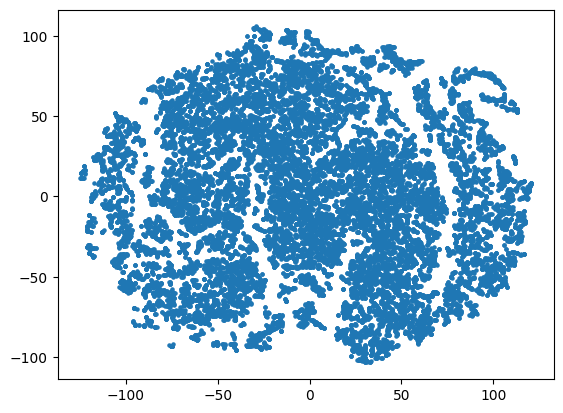

In [ ]:
plt.scatter(mus_tsne[:, 0], mus_tsne[:, 1], s=5)